# EC interpolation (no stats)
This notebook uses EC to predict the resonance energy and rotated $(r_\theta^2)$ for many $\theta$ in the training region.
EC should be able to do this fine. Then, we take a first look at EC's ability to back-rotate the resonance and predict
the energy and $(r^2)$ value of the back-rotated state.

In [4]:
from src.ecensemble import ECEnsemble
from src.ec import ECSystem, TakagiRegularization
from src.dvr import DVR

import numpy as np
from numpy import pi, exp
import random
import matplotlib.pyplot as plt

import logging
logging.basicConfig(level=logging.WARNING, format="[%(levelname)s] %(name)s: %(message)s")
logging.getLogger("matplotlib").setLevel(logging.WARNING)

In [ ]:
save_plots = True
plots_folder = Path("./plots/ec_interpolation")
plots_folder.mkdir(exist_ok=True, parents=True)

In [5]:
# define system parameters
n = 256                      # number of DVR grid points
phi = pi / 24                # rotation angle
real_res = 1.606 - 1j*0.047  # expected value of resonance
L = 50.0                     # system size

gauss_s = lambda r: 2.0 * exp(-((r-3.0)/1.5)**2) # potential

### Use EC to interpolate, predicting $E$ and $(r_\theta^2)$ in the training region

In [11]:
# get exact data
phi_predict = np.linspace(pi/24, pi/6, 20)

test_system = DVR(n, L, rotation_angle=phi, potential=gauss_s)
exact_rrs, exact_energies = [], []
for phi in phi_predict:
    test_system.reset_rotation_angle(phi)
    eigval, eigstate = test_system.closest_to_resonance(real_res)
    rr = test_system.compute_rr(eigstate[:, 0], rotate_rr=True, regulator=False)
    exact_energies.append(eigval[0])
    exact_rrs.append(rr)

# get training data and train EC
train_energies, train_rrs = [], []
phi_train = np.linspace(pi/24, pi/6, 5)
for phi in phi_train:
    test_system.reset_rotation_angle(phi)
    energy, state = test_system.closest_to_resonance(real_res)
    train_energies.append(energy[0])
    train_rrs.append(test_system.compute_rr(state[:, 0], rotate_rr=True, regulator=False))

test_EC = ECSystem(test_system, real_res)
test_EC.train(phi_train)
test_EC.construct_basis()

# use EC to predict energies and <r^2>
predict_energies, predict_rrs = test_EC.predict_energies_rrs(phi_predict, rotate_rr=True)

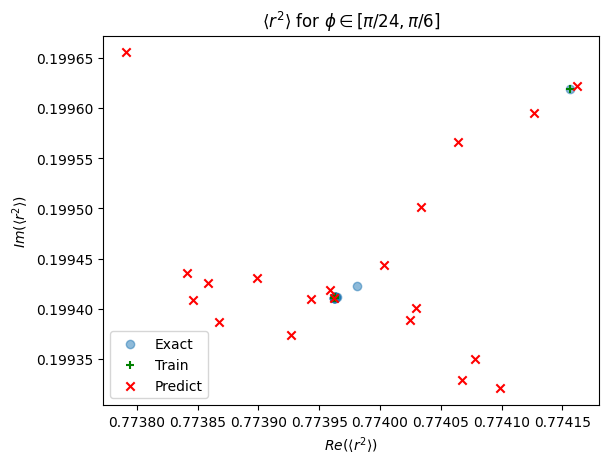

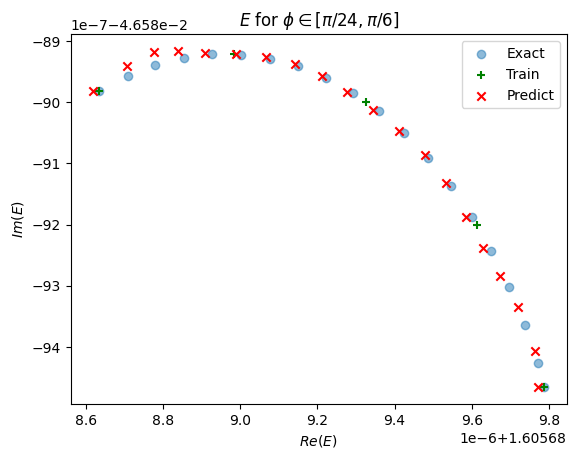

In [12]:
# plot rrs as phi changes
fig, ax = plt.subplots()
ax.scatter(np.real(exact_rrs), np.imag(exact_rrs), alpha=0.5, label="Exact")
ax.scatter(np.real(train_rrs), np.imag(train_rrs), c='green', marker='+', label="Train")
ax.scatter(np.real(predict_rrs), np.imag(predict_rrs), c='red', marker='x', label="Predict")
ax.set_xlabel(r"$Re(\langle r^2\rangle)$")
ax.set_ylabel(r"$Im(\langle r^2\rangle)$")
ax.legend()
ax.set_title(r"$\langle r^2\rangle$ for $\phi\in [\pi/24,\pi/6]$")
if save_plots:
    plt.savefig(plots_folder / "ec_radius.png")
plt.show()

fig, ax = plt.subplots()
ax.scatter(np.real(exact_energies), np.imag(exact_energies), alpha=0.5, label=r"Exact")
ax.scatter(np.real(train_energies), np.imag(train_energies), c='green', marker='+', label="Train")
ax.scatter(np.real(predict_energies), np.imag(predict_energies), c='red', marker='x', label="Predict")
ax.set_xlabel(r"$Re(E)$")
ax.set_ylabel(r"$Im(E)$")
ax.set_title(r"$E$ for $\phi\in [\pi/24,\pi/6]$")
ax.legend()
if save_plots:
    plt.savefig(plots_folder / "ec_energy.png")
plt.show()